# JOINTS x INSPIRE UGM 2026 — Forecasting Tiket Bioskop D4–D10

**Pertanyaan lomba:** seberapa jauh tiga hari pertama penayangan sebuah film (D1–D3) dapat memberi gambaran tentang tujuh hari berikutnya (D4–D10)?

| Komponen | Isi |
|---|---|
| Input | Penjualan D1–D3 setiap pasangan film × klaster bioskop, ditambah kalender, harga tiket, dan metadata |
| Output | Prediksi `total_ticket` harian D4–D10 (72.611 baris) |
| Metrik | MASE versi lomba: `mean(|y - ŷ| / scale)`, dengan `scale = max(1, rata-rata tiket D1–D3 pasangan)` |
| Model | LightGBM (objective L1) pada target rasio `tiket / scale`, rata-rata 5 seed |
| Data eksternal | Tanggal cuti bersama (SKB 3 Menteri 2025 dan 2026) dan libur sekolah (Kalender Pendidikan DKI), semua terbit sebelum 30 September 2025 |

**Ide utama notebook ini.** Train mencakup April–September 2025, sedangkan film uji tayang Oktober 2025–Maret 2026. Ada empat komponen utama:
1. **Indeks pasar.** Periode uji pasarnya jauh lebih sepi (okupansi rata-rata sekitar setengah dari train) dan memiliki musim ekstrem (Natal–Tahun Baru, Ramadan, Lebaran). Model yang hanya melihat angka absolut akan salah membaca film "normal" di pasar sepi sebagai film yang lemah. Kami membangun indeks pasar dari penjualan D1–D3 film-film baru (tersedia di `train.csv` dan `test_history.csv`). Indeks ini dipakai untuk menormalkan performa awal film terhadap kondisi pasar dan memperkirakan perubahan permintaan ke tanggal target.
2. **Augmentasi jendela bergeser.** Train hanya punya 205 film. Dengan menggeser awal jendela 1–14 hari (D1' = D1 + s), satu film menghasilkan banyak sampel "3 hari teramati → 7 hari berikutnya", sehingga data latih bertambah sekitar 9 kali lipat.
3. **Hari libur efektif** (akhir pekan + libur nasional + cuti bersama) dan **libur sekolah**, terutama jumlah hari libur di dalam D1–D3, karena D1–D3 yang jatuh di hari libur membuat skala menggelembung.
4. **Kalibrasi level per musim × horizon** ke level yang sudah teruji di public LB, karena level penjualan di musim yang tidak ada di train (Natal, Ramadan, Lebaran) tidak bisa dipelajari dari train.

Alur notebook: Instalasi → Import → Data Acquisition → EDA → Preprocessing & Data Cleaning → Feature Engineering → Modeling → Evaluation → Postprocessing → Submission.

# 1. Instalasi dependency

In [1]:
%pip install -q numpy==2.4.4 pandas==2.3.3 scikit-learn==1.8.0 lightgbm==4.6.0 matplotlib==3.10.9 joblib==1.5.3

Note: you may need to restart the kernel to use updated packages.


# 2. Import library dan random state

In [2]:
import os, glob, random, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore", category=RuntimeWarning)  # nanmedian pada tanggal tanpa data
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

Satu konstanta `SEED` dipakai di semua proses acak (subsample/colsample LightGBM). Model akhir adalah rata-rata 5 model dengan seed `SEED, SEED+1, ..., SEED+4`, sehingga hasil dapat direproduksi persis oleh panitia (`deterministic=True`, `force_row_wise=True`).

In [3]:
SEED = 42
SEEDS = [SEED + i for i in range(5)]
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print("SEED =", SEED, "| SEEDS =", SEEDS)

SEED = 42 | SEEDS = [42, 43, 44, 45, 46]


# 3. Data Acquisition

In [4]:
_DATA_DIR_CANDIDATES = [
    "../data", "data", "../../data", "./input",
    *glob.glob("/kaggle/input/*"), *glob.glob("/kaggle/input/**/", recursive=True),
]
DATA_DIR = next((d for d in _DATA_DIR_CANDIDATES if d and os.path.exists(os.path.join(d, "test_history.csv"))), None)
if DATA_DIR is None:
    raise FileNotFoundError("test_history.csv tidak ditemukan, set DATA_DIR secara manual.")
print("DATA_DIR =", os.path.abspath(DATA_DIR))

train = pd.read_csv(f"{DATA_DIR}/train.csv", parse_dates=["date_show"])
test_hist = pd.read_csv(f"{DATA_DIR}/test_history.csv", parse_dates=["date_show"])
test = pd.read_csv(f"{DATA_DIR}/test.csv", parse_dates=["date_show"])
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")
movies = pd.read_csv(f"{DATA_DIR}/movies.csv")
holidays = pd.read_csv(f"{DATA_DIR}/holidays.csv", parse_dates=["date"])
prices = pd.read_csv(f"{DATA_DIR}/ticket_prices.csv")

pd.DataFrame({
    name: {"rows": len(df), "cols": df.shape[1], "missing": int(df.isna().sum().sum()), "duplicates": int(df.duplicated().sum())}
    for name, df in {"train": train, "test_history": test_hist, "test": test, "sample_sub": sample_sub,
                     "movies": movies, "holidays": holidays, "prices": prices}.items()
}).T

DATA_DIR = D:\Lomba\Data Science\Joints\JOINTS\data


,rows,cols,missing,duplicates
train,138959,7,0,0
test_history,32323,7,0,0
test,72611,5,0,0
sample_sub,72611,2,0,0
movies,397,7,3,0
holidays,366,4,348,0
prices,207,3,0,0


### 3.1 Data eksternal: cuti bersama
`holidays.csv` hanya memuat libur nasional, tanpa **cuti bersama**, padahal cuti bersama juga menjadi hari libur bagi banyak orang (misalnya 26 Desember 2025 dan 20, 23, 24 Maret 2026 di sekitar Lebaran). Tanggal cuti bersama kami ambil dari dokumen resmi pemerintah yang terbit **sebelum batas 30 September 2025**:

| Periode | Sumber | Tanggal terbit | Tanggal cuti bersama yang dipakai |
|---|---|---|---|
| 2025 | SKB Menteri Agama, Menaker, dan MenPAN-RB tentang Hari Libur Nasional dan Cuti Bersama 2025 ([Kompas TV](https://www.kompas.tv/lifestyle/545883/link-pdf-skb-3-menteri-tentang-libur-nasional-dan-cuti-bersama-2025-ada-berapa-tanggal-merah), [Bisnis.com](https://kabar24.bisnis.com/read/20250102/15/1828492/jadwal-hari-libur-dan-cuti-bersama-2025)) | Oktober 2024 | 28 Jan, 28 Mar, 2–4 & 7 Apr, 13 Mei, 30 Mei, 9 Jun, 26 Des 2025 |
| 18 Agustus 2025 | SKB perubahan, cuti bersama HUT RI ([NU Online](https://www.nu.or.id/nasional/skb-tiga-menteri-tetapkan-cuti-bersama-pada-18-agustus-2025-PnHTC)) | Agustus 2025 | 18 Agu 2025 |
| 2026 | SKB No. 1497/2/5 Tahun 2025 tentang Hari Libur Nasional dan Cuti Bersama 2026, ditandatangani 19 September 2025 ([Setneg](https://setneg.go.id/baca/index/inilah_skb_3_menteri_libur_nasional_dan_cuti_bersama_2026), [CNBC Indonesia 19-09-2025](https://www.cnbcindonesia.com/lifestyle/20250919174306-33-668589/catat-daftar-17-hari-libur-nasional-8-hari-cuti-bersama-tahun-2026)) | 19 September 2025 | 16 Feb, 18 Mar, 20 Mar, 23–24 Mar 2026 |

### 3.2 Data eksternal: libur sekolah
Libur akhir semester dan libur Lebaran sekolah membuat hari kerja biasa berperilaku seperti hari libur (contoh: 29–31 Desember dan 25–27 Maret). Tanggalnya diambil dari Kalender Pendidikan DKI Jakarta (provinsi dengan pasar bioskop terbesar):

| Periode | Sumber | Tanggal terbit |
|---|---|---|
| Tahun ajaran 2024/2025 | Kalender Pendidikan DKI Jakarta 2024/2025 (diberitakan tirto.id dan detik.com) | 2024 |
| Tahun ajaran 2025/2026 | Keputusan Kepala Dinas Pendidikan Provinsi DKI Jakarta No. 89 Tahun 2025 tentang Kalender Pendidikan 2025/2026 (sinotif.com 11-07-2025, detik.com 07-08-2025) | Juli 2025 |

Periode yang dipakai: 25 Mar–7 Apr 2025 (Idulfitri), 28 Jun–13 Jul 2025 (kenaikan kelas), 22 Des 2025–4 Jan 2026 (semester ganjil), 16–20 Feb 2026 (awal Ramadan), 16–27 Mar 2026 (Idulfitri).

Kedua data eksternal ini hanya berupa daftar tanggal (diakses Oktober 2026), terbit sebelum 30 September 2025, dan dipakai sebagai fitur kalender. Tidak ada informasi tentang film uji di dalamnya.

In [5]:
CUTI_BERSAMA = pd.to_datetime([
    # SKB 3 Menteri cuti bersama 2025 (terbit Oktober 2024) + SKB 18 Agustus 2025
    "2025-01-28", "2025-03-28", "2025-04-02", "2025-04-03", "2025-04-04", "2025-04-07", "2025-05-13",
    "2025-05-30", "2025-06-09", "2025-08-18", "2025-12-26",
    # SKB 3 Menteri No. 1497/2/5 Tahun 2025 tentang cuti bersama 2026 (ditandatangani 19 September 2025)
    "2026-02-16", "2026-03-18", "2026-03-20", "2026-03-23", "2026-03-24",
])
SCHOOL_HOLIDAYS = [("2025-03-25", "2025-04-07"), ("2025-06-28", "2025-07-13"), ("2025-12-22", "2026-01-04"),
                   ("2026-02-16", "2026-02-20"), ("2026-03-16", "2026-03-27")]
SCHOOL_DAYS = pd.DatetimeIndex(np.concatenate([pd.date_range(a, b) for a, b in SCHOOL_HOLIDAYS]))
print("cuti bersama:", len(CUTI_BERSAMA), "hari | libur sekolah:", len(SCHOOL_DAYS), "hari")

cuti bersama: 16 hari | libur sekolah: 61 hari


# 4. Exploratory Data Analysis

### 4.1 Rentang waktu dan irisan train–test
Hal pertama yang perlu dipastikan: apakah film uji berada dalam periode train atau setelahnya, dan berapa banyak film/klaster uji yang pernah muncul di train.

In [6]:
for name, df in {"train": train, "test_history": test_hist, "test": test}.items():
    print(f"{name:13s}: {df['date_show'].min().date()} s.d. {df['date_show'].max().date()}")
for col in ["movie_title", "cinema_ids", "city_name"]:
    tr, te = set(train[col]), set(test[col])
    print(f"{col:12s}: train {len(tr):4d} | test {len(te):4d} | overlap {len(tr & te):4d}")

train        : 2025-04-01 s.d. 2025-09-30
test_history : 2025-10-01 s.d. 2026-03-20
test         : 2025-10-04 s.d. 2026-03-27
movie_title : train  237 | test  160 | overlap   10
cinema_ids  : train  117 | test  121 | overlap  117
city_name   : train   67 | test   69 | overlap   67


Film uji tayang **setelah** periode train, dan hanya 10 dari 160 film uji yang pernah muncul di train. Sebaliknya, hampir semua klaster uji ada di train. Artinya model harus belajar pola umum dari film lain (*cold start*), dan validasi harus dikelompokkan per film.

### 4.2 Distribusi tiket harian
`total_ticket` sangat timpang antar film dan klaster, sehingga ditampilkan dalam skala log.

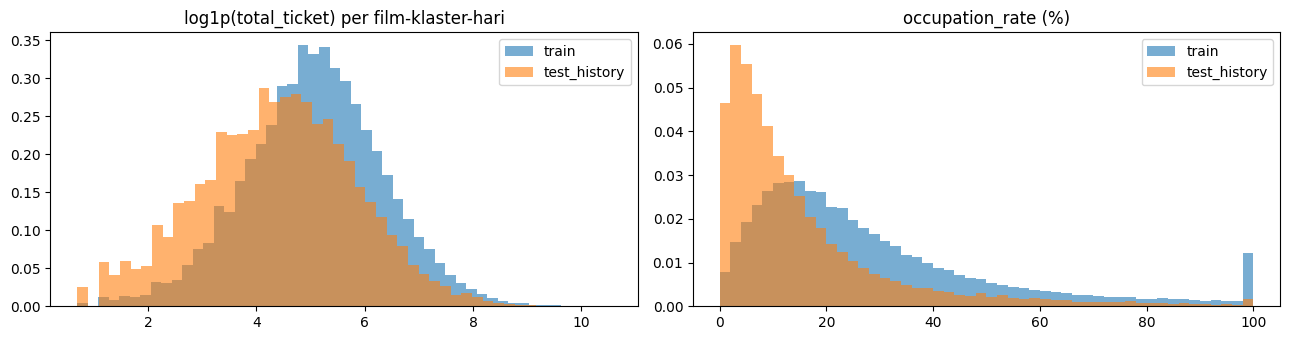

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].hist(np.log1p(train["total_ticket"]), bins=50, alpha=0.6, density=True, label="train")
ax[0].hist(np.log1p(test_hist["total_ticket"]), bins=50, alpha=0.6, density=True, label="test_history")
ax[0].set_title("log1p(total_ticket) per film-klaster-hari"); ax[0].legend()
ax[1].hist(train["occupation_rate"], bins=50, alpha=0.6, density=True, label="train")
ax[1].hist(test_hist["occupation_rate"], bins=50, alpha=0.6, density=True, label="test_history")
ax[1].set_title("occupation_rate (%)"); ax[1].legend()
plt.tight_layout(); plt.show()

### 4.3 Penentuan D1 di train dan bentuk kurva D1–D10
Train adalah data mentah tanpa label D1. Film biasanya punya beberapa hari *preview* di sedikit klaster sebelum tayang luas, sedangkan D1 pada test adalah hari tayang luas (tanggal pertama `test_history`). Karena itu D1 train didefinisikan sebagai **tanggal pertama film tayang di minimal 50% dari jumlah klaster maksimalnya**.

test D1 = tanggal pertama test_history: 1.0


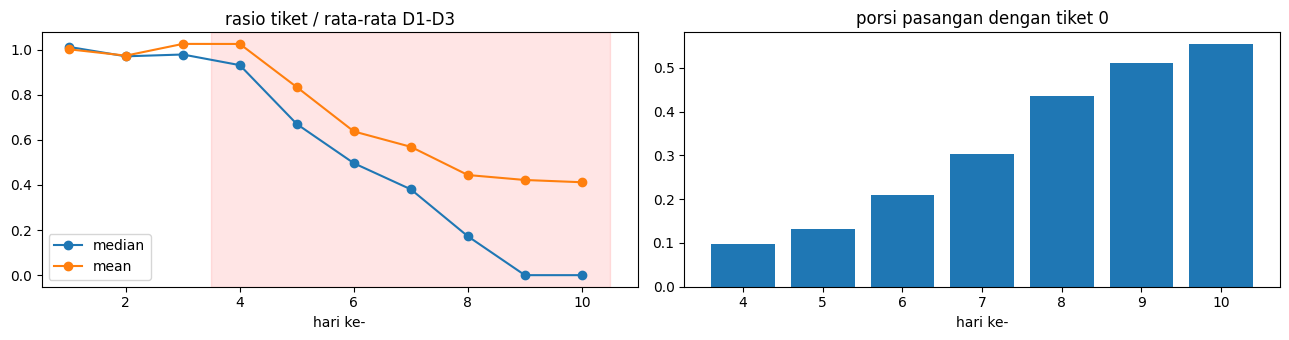

In [8]:
clusters_per_day = train.groupby(["movie_title", "date_show"])["cinema_ids"].nunique()
first_date = train.groupby("movie_title")["date_show"].min()
wide_days = clusters_per_day[clusters_per_day >= 0.5 * clusters_per_day.groupby(level=0).transform("max")]
train_d1_all = wide_days.reset_index().groupby("movie_title")["date_show"].min()   # semua film train
test_d1 = test.groupby("movie_title")["date_show"].min() - pd.Timedelta(days=3)

print("test D1 = tanggal pertama test_history:",
      (test_hist.groupby("movie_title")["date_show"].min().reindex(test_d1.index) == test_d1).mean())

# kurva rasio tiket terhadap rata-rata D1-D3 (skala MASE) per hari
_t = train.assign(day=(train["date_show"] - train["movie_title"].map(train_d1_all)).dt.days + 1)
_t = _t[_t["day"].between(1, 10)].pivot_table(index=["movie_title", "cinema_ids"], columns="day",
                                               values="total_ticket", fill_value=0)
_t = _t[_t[3] > 0]
_ratio = _t.div(_t[[1, 2, 3]].mean(axis=1).clip(lower=1), axis=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
ax[0].plot(_ratio.columns, _ratio.median(), marker="o", label="median")
ax[0].plot(_ratio.columns, _ratio.mean(), marker="o", label="mean")
ax[0].axvspan(3.5, 10.5, alpha=0.1, color="red"); ax[0].set_xlabel("hari ke-"); ax[0].set_title("rasio tiket / rata-rata D1-D3")
ax[0].legend()
ax[1].bar(_ratio.columns[3:], (_t[list(range(4, 11))] == 0).mean().values)
ax[1].set_title("porsi pasangan dengan tiket 0"); ax[1].set_xlabel("hari ke-")
plt.tight_layout(); plt.show()

Rasio median turun dari sekitar 0,9 di D4 hingga 0 di D9–D10, dan porsi nol naik tajam (film mulai turun layar di klaster kecil). Distribusi target ini sangat *zero-inflated* dan miring ke kanan. Karena metriknya adalah error absolut, prediktor optimalnya adalah **median bersyarat**, bukan rata-rata. Inilah alasan kami memakai objective L1.

### 4.4 Pergeseran pasar: periode train vs periode uji
Grafik di bawah membandingkan kondisi pasar dari waktu ke waktu memakai median okupansi pasangan film-klaster pada D1–D3 film-film baru. Data ini tersedia untuk train maupun test (`test_history`).

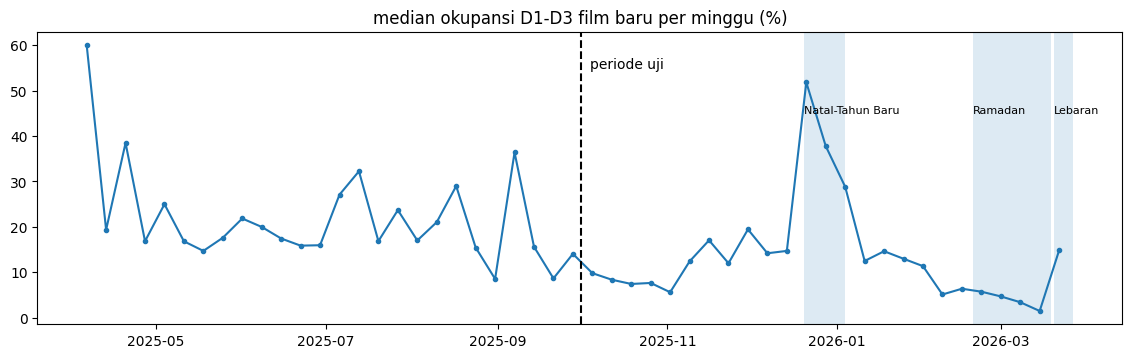

median okupansi D1-D3  train: 20.1 | test: 10.0


In [9]:
_a = train.assign(k=(train["date_show"] - train["movie_title"].map(train_d1_all)).dt.days + 1)
_b = test_hist.assign(k=(test_hist["date_show"] - test_hist["movie_title"].map(test_d1)).dt.days + 1)
new_release = pd.concat([_a, _b])
new_release = new_release[new_release["k"].between(1, 3)].copy()
new_release["tps"] = new_release["total_ticket"] / new_release["total_show"].replace(0, np.nan)

weekly = new_release.set_index("date_show").resample("W")[["occupation_rate", "tps"]].median()
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(weekly.index, weekly["occupation_rate"], marker="o", ms=3)
ax.axvline(pd.Timestamp("2025-10-01"), color="k", ls="--"); ax.text(pd.Timestamp("2025-10-04"), 55, "periode uji")
for a, b, lab in [("2025-12-20", "2026-01-04", "Natal-Tahun Baru"), ("2026-02-19", "2026-03-19", "Ramadan"),
                  ("2026-03-20", "2026-03-27", "Lebaran")]:
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), alpha=0.15); ax.text(pd.Timestamp(a), 45, lab, fontsize=8)
ax.set_title("median okupansi D1-D3 film baru per minggu (%)"); plt.show()

print("median okupansi D1-D3  train: %.1f | test: %.1f" % (
    _a[_a["k"].between(1, 3)]["occupation_rate"].median(), _b[_b["k"].between(1, 3)]["occupation_rate"].median()))

Temuan penting:
- Pasar di periode uji **jauh lebih sepi** (median okupansi D1–D3 kira-kira setengah dari train), kecuali pada Natal–Tahun Baru.
- Ramadan sangat sepi, terutama minggu terakhirnya, kemudian Lebaran melonjak tajam. Train dimulai tepat pada hari Lebaran 2025, sehingga **pola Ramadan → Lebaran tidak pernah terlihat oleh model**.
- Model yang memakai okupansi atau volume absolut akan menganggap film normal di pasar sepi sebagai film lemah yang cepat turun layar, dan film normal di pasar ramai (Natal) sebagai film kuat. Ini menjadi motivasi fitur **relatif terhadap pasar** di bagian Feature Engineering.

### 4.5 Pola hari dan hari libur

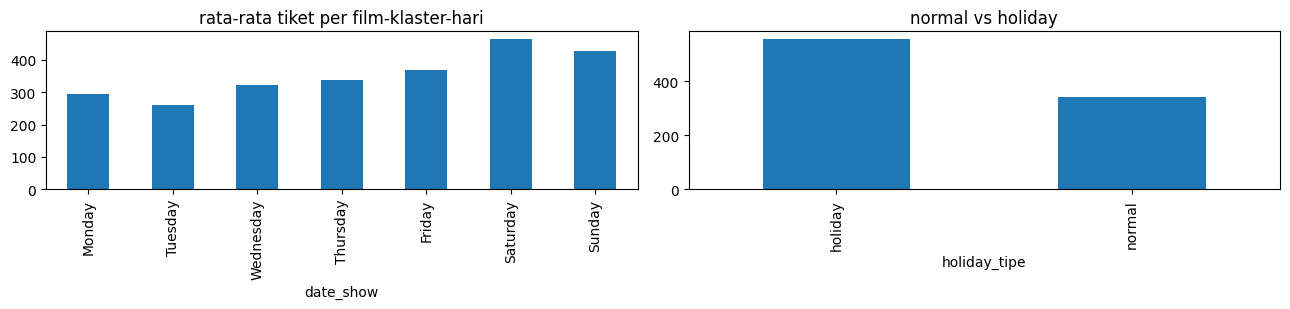

hari D1 film uji: {'Thursday': 65, 'Wednesday': 64, 'Friday': 24, 'Saturday': 5, 'Tuesday': 2}


In [10]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
cal = train.merge(holidays.rename(columns={"date": "date_show"}), on="date_show", how="left")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
cal.groupby(cal["date_show"].dt.day_name())["total_ticket"].mean().reindex(DAY_ORDER).plot(kind="bar", ax=ax[0])
ax[0].set_title("rata-rata tiket per film-klaster-hari")
cal.groupby("holiday_tipe")["total_ticket"].mean().plot(kind="bar", ax=ax[1]); ax[1].set_title("normal vs holiday")
plt.tight_layout(); plt.show()
print("hari D1 film uji:", test_d1.dt.day_name().value_counts().to_dict())

### 4.6 Skala pasangan train vs test
Metrik membagi error dengan skala pasangan, sehingga pasangan berskala kecil sangat berpengaruh. Test memiliki jauh lebih banyak pasangan kecil.

In [11]:
tr_scale = _t[[1, 2, 3]].mean(axis=1).clip(lower=1)
th3 = test_hist.assign(k=(test_hist["date_show"] - test_hist["movie_title"].map(test_d1)).dt.days + 1)
te_scale = (th3.groupby(["movie_title", "cinema_ids"])["total_ticket"].sum() / 3).clip(lower=1)
te_scale = te_scale.reindex(pd.MultiIndex.from_frame(test[["movie_title", "cinema_ids"]].drop_duplicates()))
bins = [0, 10, 20, 50, 100, 300, np.inf]
pd.DataFrame({"train": pd.cut(tr_scale, bins).value_counts(normalize=True).sort_index(),
              "test": pd.cut(te_scale, bins).value_counts(normalize=True).sort_index()}).round(3)

,train,test
"(0.0, 10.0]",0.011,0.050
"(10.0, 20.0]",0.022,0.080
"(20.0, 50.0]",0.107,0.198
"(50.0, 100.0]",0.169,0.200
"(100.0, 300.0]",0.353,0.286
"(300.0, inf]",0.337,0.186


# 5. Preprocessing & Data Cleaning

### 5.1 Pemilihan film train
Film train dibuang jika:
- sudah tayang sejak awal data (D1 tidak teramati), atau
- D10-nya jatuh setelah 30 September 2025 (target tidak lengkap).

In [12]:
train_d1 = train_d1_all[(first_date[train_d1_all.index] > train["date_show"].min())
                        & (train_d1_all + pd.Timedelta(days=9) <= train["date_show"].max())]
print(f"film train terpakai: {len(train_d1)} dari {train['movie_title'].nunique()} | film test: {len(test_d1)}")

film train terpakai: 205 dari 237 | film test: 160


### 5.2 Jendela D1–D10 per pasangan film-klaster
Transaksi diubah ke format lebar per pasangan (tiket, okupansi, jumlah show untuk setiap hari). **Hari tanpa transaksi diisi 0**, sesuai aturan lomba (tidak tayang berarti target 0). Pasangan train hanya diambil jika masih ada penjualan di D3, karena test hanya berisi pasangan yang masih tayang di D3.

In [13]:
PIVOT_COLS = {"total_ticket": "t", "occupation_rate": "occ", "total_show": "show"}
CLUSTER_CITY = pd.concat([train, test_hist]).drop_duplicates("cinema_ids").set_index("cinema_ids")["city_name"]


def build_window(hist, d1_map, n_days):
    df = hist[hist["movie_title"].isin(d1_map.index)].copy()
    df["day"] = (df["date_show"] - df["movie_title"].map(d1_map)).dt.days + 1
    df = df[df["day"].between(1, n_days)]
    parts = []
    for col, prefix in PIVOT_COLS.items():
        p = df.pivot_table(index=["movie_title", "cinema_ids"], columns="day", values=col, fill_value=0)
        p = p.reindex(columns=range(1, n_days + 1), fill_value=0)
        p.columns = [f"{prefix}{d}" for d in p.columns]
        parts.append(p)
    out = pd.concat(parts, axis=1).reset_index()
    out["d1_date"] = out["movie_title"].map(d1_map)
    return out


train_window = build_window(train, train_d1, 10)
test_window = build_window(test_hist, test_d1, 3)
train_pairs = train_window[train_window["t3"] > 0].reset_index(drop=True)
test_pairs = test_window.merge(test[["movie_title", "cinema_ids"]].drop_duplicates(), on=["movie_title", "cinema_ids"])
print(f"pasangan train: {len(train_pairs)} | pasangan test: {len(test_pairs)} | "
      f"pasangan unik test.csv: {len(test[['movie_title', 'cinema_ids']].drop_duplicates())}")

pasangan train: 8007 | pasangan test: 10373 | pasangan unik test.csv: 10373


### 5.3 Format harian (satu baris = satu tanggal target)
Setiap pasangan diubah menjadi 7 baris D4–D10 seperti `test.csv`.

In [14]:
HORIZONS = range(4, 11)
BASE_COLS = ["movie_title", "cinema_ids", "d1_date"] + [f"{p}{d}" for p in PIVOT_COLS.values() for d in (1, 2, 3)]


def to_long(pairs, with_target):
    rows = []
    for h in HORIZONS:
        r = pairs[BASE_COLS].copy()
        r["horizon"] = h
        r["date_show"] = r["d1_date"] + pd.Timedelta(days=h - 1)
        if with_target:
            r["total_ticket"] = pairs[f"t{h}"].values
        rows.append(r)
    return pd.concat(rows, ignore_index=True)


train_long = to_long(train_pairs, with_target=True)
test_long = to_long(test_pairs, with_target=False)
print(f"baris train: {len(train_long)} | baris test: {len(test_long)} | baris test.csv: {len(test)}")

baris train: 56049 | baris test: 72611 | baris test.csv: 72611


# 6. Feature Engineering

### 6.1 Fitur pasangan (D1–D3 pasangan itu sendiri)
- `scale`: rata-rata tiket D1–D3 dengan batas bawah 1, sama persis dengan skala MASE.
- `trend`, `t3_share`: arah penjualan selama D1–D3.
- `occ_mean`, `show_mean`, `show3`, `tickets_per_show3`: okupansi dan alokasi show.
- `active_days`: jumlah hari D1–D3 dengan transaksi (pasangan yang baru mulai tayang di D2/D3 berperilaku sangat berbeda).

In [15]:
def add_pair_features(df):
    df["scale"] = df[["t1", "t2", "t3"]].mean(axis=1).clip(lower=1)
    df["trend"] = (df["t3"] + 1) / (df["t1"] + 1)
    df["t3_share"] = df["t3"] / df[["t1", "t2", "t3"]].sum(axis=1)
    df["occ_mean"] = df[["occ1", "occ2", "occ3"]].mean(axis=1)
    df["show_mean"] = df[["show1", "show2", "show3"]].mean(axis=1)
    df["tickets_per_show3"] = df["t3"] / df["show3"].replace(0, np.nan)
    df["active_days"] = (df[["t1", "t2", "t3"]] > 0).sum(axis=1)
    return df

### 6.2 Fitur film (agregat nasional D1–D3)
Pola naik-turun sebuah film biasanya mirip di semua klaster, jadi total nasional D1–D3 menjadi sinyal yang kuat: `mv_t1..3`, `mv_trend`, `mv_clusters` (jumlah klaster yang masih menjual di D3), dan `pair_share`.

In [16]:
def movie_features(window):
    g = window.groupby("movie_title")
    mv = g[["t1", "t2", "t3"]].sum().add_prefix("mv_")
    mv["mv_clusters"] = g["t3"].apply(lambda s: (s > 0).sum())
    mv["mv_trend"] = (mv["mv_t3"] + 1) / (mv["mv_t1"] + 1)
    return mv.reset_index()

### 6.3 Fitur klaster
Rata-rata skala D1–D3 setiap klaster dari semua film (train + test_history), sebagai ukuran besar-kecilnya klaster. Fitur ini tidak memakai target D4–D10.

In [17]:
all_windows = pd.concat([train_window, test_window], ignore_index=True)
cluster_feats = (all_windows.assign(pair_scale=all_windows[["t1", "t2", "t3"]].mean(axis=1))
                 .groupby("cinema_ids").agg(cl_scale=("pair_scale", "mean"), cl_movies=("movie_title", "nunique"))
                 .reset_index())

### 6.4 Fitur kalender dan harga
Hari dalam minggu, tipe hari, status libur tanggal target, hari D1, harga tiket kota pada tanggal target, serta rasio harga target terhadap D1–D3.

In [18]:
CALENDAR = holidays.rename(columns={"date": "date_show"})[["date_show", "day_tipe", "holiday_tipe"]]
DAY_TIPE = CALENDAR.set_index("date_show")["day_tipe"]
PRICE_DAY = {"weekday": "Weekday", "friday": "Friday", "weekend": "Weekend"}
PRICE_MAP = prices.set_index(["city_name", "price_day"])["ceil"]


def price_of(city, dates):
    price_day = dates.map(DAY_TIPE).map(PRICE_DAY)
    return pd.Series(PRICE_MAP.reindex(list(zip(city, price_day))).values, index=city.index)


def add_calendar_features(df):
    df = df.merge(CALENDAR, on="date_show", how="left")
    df["dow"] = df["date_show"].dt.dayofweek
    df["d1_dow"] = df["d1_date"].dt.dayofweek
    df["is_holiday"] = (df["holiday_tipe"] == "holiday").astype(int)
    df["price"] = price_of(df["city_name"], df["date_show"])
    d13_price = pd.concat([price_of(df["city_name"], df["d1_date"] + pd.Timedelta(days=k)) for k in range(3)], axis=1)
    df["price_ratio"] = df["price"] / d13_price.mean(axis=1)
    return df

### 6.5 Indeks pasar (kontribusi utama notebook ini)
Untuk setiap tanggal, kami menghitung **median kondisi pasar** dari semua pasangan film-klaster yang sedang berada di D1–D3 (film baru) dalam jendela ±w hari. Ada tiga ukuran: okupansi (`M_occ`), tiket per show (`M_tps`), dan tiket per pasangan (`M_tk`). Indeks ini dibangun dengan cara yang **sama persis** untuk train (dari `train.csv`) dan test (dari `test_history.csv`), dan **tidak memakai target D4–D10 sama sekali**.

Dua kelompok fitur diturunkan dari indeks ini:
1. **Performa relatif saat rilis** (w = 10 hari): `occ_rel = occ_mean / M_occ`, `tps_rel`, `mvt_rel`, `mv_pc_rel` (volume nasional per klaster relatif terhadap pasar). Bioskop memutuskan mempertahankan atau menurunkan film berdasarkan performa relatifnya terhadap film lain, bukan angka absolut.
2. **Perubahan pasar ke tanggal target** (w = 3 hari): `mr_M_occ = M_occ(tanggal target) / rata-rata geometrik M_occ(D1..D3)`, begitu pula `mr_M_tps`. Fitur ini menangkap minggu ramai/sepi berikutnya (misalnya libur akhir tahun) dari penjualan D1–D3 film-film lain yang rilis di sekitar tanggal target. Tanggal tanpa film baru diisi dengan interpolasi linear.

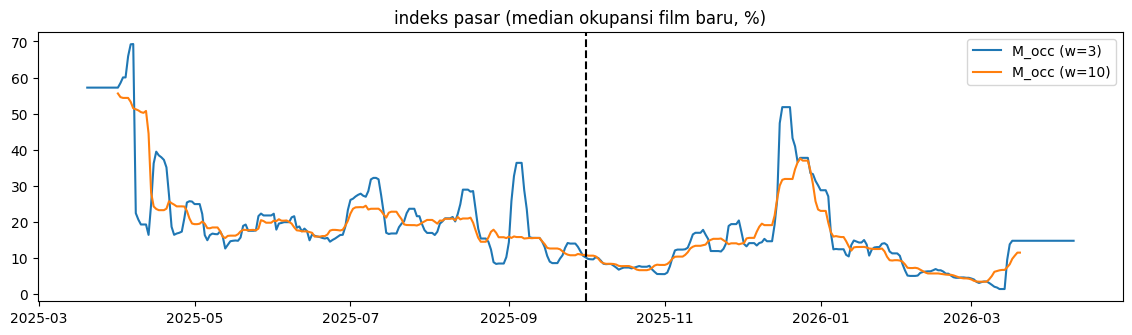

date,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01
M_occ,25.5,18.2,17.8,22.6,20.1,13.4,8.1,13.5,25.8,13.1,5.8,6.3
M_tps,36.0,27.6,26.7,32.8,30.8,19.5,12.4,21.0,36.6,19.8,9.0,10.4
M_tk,200.2,147.0,138.5,186.0,150.0,108.5,75.0,119.5,210.0,102.0,43.0,51.5


In [19]:
def market_index(win):
    by = new_release.groupby("date_show")
    occ, tps, tk = by["occupation_rate"].apply(list), by["tps"].apply(list), by["total_ticket"].apply(list)
    rows = []
    for d in pd.date_range(new_release["date_show"].min(), new_release["date_show"].max()):
        w = [x for x in pd.date_range(d - pd.Timedelta(days=win), d + pd.Timedelta(days=win)) if x in occ.index]
        if not w:
            rows.append((d, np.nan, np.nan, np.nan)); continue
        rows.append((d, np.nanmedian(np.concatenate([occ[x] for x in w])),
                     np.nanmedian(np.concatenate([tps[x] for x in w])),
                     np.nanmedian(np.concatenate([tk[x] for x in w]))))
    return pd.DataFrame(rows, columns=["date", "M_occ", "M_tps", "M_tk"]).set_index("date")


MARKET_REL = market_index(10)                                    # kondisi pasar saat rilis
MARKET_TGT = (market_index(3).reindex(pd.date_range("2025-03-20", "2026-04-10"))
              .interpolate(limit_direction="both"))              # kondisi pasar harian untuk tanggal target

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(MARKET_TGT.index, MARKET_TGT["M_occ"], label="M_occ (w=3)")
ax.plot(MARKET_REL.index, MARKET_REL["M_occ"], label="M_occ (w=10)")
ax.axvline(pd.Timestamp("2025-10-01"), color="k", ls="--"); ax.legend(); ax.set_title("indeks pasar (median okupansi film baru, %)")
plt.show()
MARKET_REL.resample("MS").median().round(1).T

In [20]:
def add_market_features(df):
    d2 = df["d1_date"] + pd.Timedelta(days=1)
    for c in MARKET_REL.columns:
        df[c] = d2.map(MARKET_REL[c]).values
    mvt = df["mv_t1"] + df["mv_t2"] + df["mv_t3"]
    df["occ_rel"] = df["occ_mean"] / df["M_occ"]
    df["tps_rel"] = df["tickets_per_show3"] / df["M_tps"]
    df["mvt_rel"] = mvt / df["M_tk"]
    df["mv_pc_rel"] = mvt / df["mv_clusters"].clip(lower=1) / df["M_tk"]
    for col in ["M_occ", "M_tps"]:
        d13 = np.mean([np.log(df["d1_date"].add(pd.Timedelta(days=k)).map(MARKET_TGT[col]).values) for k in range(3)], axis=0)
        df["mr_" + col] = np.exp(np.log(df["date_show"].map(MARKET_TGT[col]).values) - d13)
    return df

### 6.6 Fitur hari libur efektif dan libur sekolah (data eksternal)
Hari libur efektif = akhir pekan, libur nasional (`holidays.csv`), atau cuti bersama (SKB 3 Menteri).
- `is_offday`, `is_cuti`: status tanggal target.
- `offday_d13`: jumlah hari libur efektif di D1–D3. Jika D1–D3 banyak jatuh di hari libur, skala pasangan menggelembung sehingga rasio D4–D10 cenderung lebih rendah.
- `school_tgt`, `school_d13`: apakah tanggal target berada di libur sekolah, dan berapa hari D1–D3 yang berada di libur sekolah. Tanpa fitur ini, model menganggap 29–31 Desember sebagai hari kerja biasa setelah libur Natal, padahal masih puncak liburan akhir tahun.

In [21]:
HOLIDAY_DATES = pd.DatetimeIndex(holidays.loc[holidays["holiday_tipe"] == "holiday", "date"])


def offday(dates):
    d = pd.DatetimeIndex(dates)
    return (d.dayofweek >= 5) | d.isin(HOLIDAY_DATES) | d.isin(CUTI_BERSAMA)


def add_offday_features(df):
    t = pd.DatetimeIndex(df["date_show"])
    df["is_cuti"] = t.isin(CUTI_BERSAMA).astype(int)
    df["is_offday"] = offday(t).astype(int)
    df["offday_d13"] = np.sum([offday(df["d1_date"] + pd.Timedelta(days=k)) for k in range(3)], axis=0)
    df["school_tgt"] = t.isin(SCHOOL_DAYS).astype(int)
    df["school_d13"] = np.sum([pd.DatetimeIndex(df["d1_date"] + pd.Timedelta(days=k)).isin(SCHOOL_DAYS) for k in range(3)], axis=0)
    return df

### 6.7 Penggabungan fitur

In [22]:
def make_features(long, window, shift=0):
    df = add_pair_features(long.copy())
    df = df.merge(movie_features(window), on="movie_title", how="left")
    df["pair_share"] = df[["t1", "t2", "t3"]].sum(axis=1) / (df["mv_t1"] + df["mv_t2"] + df["mv_t3"])
    df = df.merge(cluster_feats, on="cinema_ids", how="left")
    df["city_name"] = df["cinema_ids"].map(CLUSTER_CITY)
    df = add_calendar_features(df)
    df = add_market_features(df)
    df = add_offday_features(df)
    df["shift"] = shift   # 0 = jendela asli (D1 = hari tayang luas), > 0 = sampel augmentasi
    return df


train_feat = make_features(train_long, train_window)
test_feat = make_features(test_long, test_window)

CAT_COLS = ["city_name", "day_tipe"]
for c in CAT_COLS:
    cats = pd.Categorical(pd.concat([train_feat[c], test_feat[c]])).categories
    train_feat[c] = pd.Categorical(train_feat[c], categories=cats)
    test_feat[c] = pd.Categorical(test_feat[c], categories=cats)

# Target: rasio terhadap skala. Dengan objective L1, error pada rasio = MASE persis.
train_feat["target_ratio"] = train_feat["total_ticket"] / train_feat["scale"]
print(f"train_feat: {train_feat.shape} | test_feat: {test_feat.shape}")
print("missing indeks pasar test:", test_feat[["M_occ", "mr_M_occ", "mr_M_tps"]].isna().sum().to_dict())

train_feat: (56049, 54) | test_feat: (72611, 52)
missing indeks pasar test: {'M_occ': 0, 'mr_M_occ': 0, 'mr_M_tps': 0}


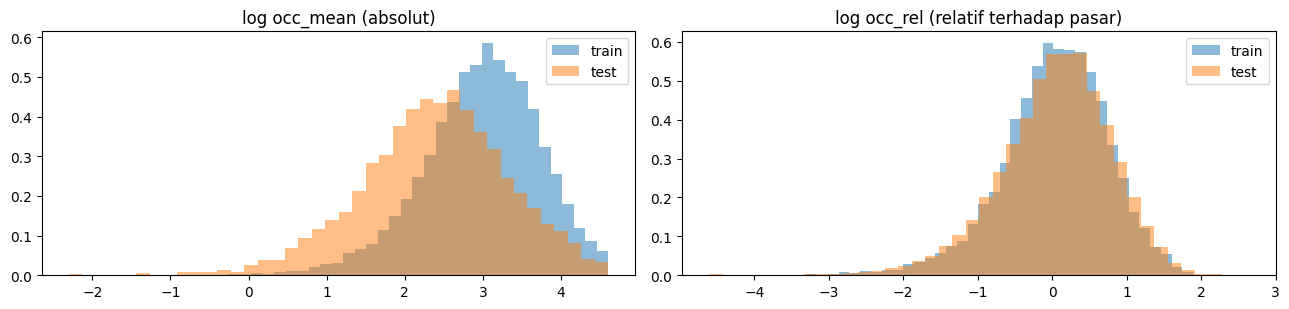

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
for name, df in [("train", train_feat), ("test", test_feat)]:
    ax[0].hist(np.log(df["occ_mean"] + 0.1), bins=40, alpha=0.5, density=True, label=name)
    ax[1].hist(np.log(df["occ_rel"] + 0.01), bins=40, alpha=0.5, density=True, label=name)
ax[0].set_title("log occ_mean (absolut)"); ax[1].set_title("log occ_rel (relatif terhadap pasar)")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

Distribusi okupansi absolut test bergeser jauh ke kiri dari train. Setelah dinormalkan dengan indeks pasar, distribusi train dan test menjadi jauh lebih mirip, sehingga pola yang dipelajari model dari train lebih bisa ditransfer ke periode uji.

### 6.8 Augmentasi data: jendela bergeser
Train hanya berisi 205 film, sedangkan pola peluruhan penjualan perlu dipelajari dari banyak contoh. Untuk setiap pergeseran `s = 1..14` hari, kami membentuk jendela baru dengan D1' = D1 + s: tiga hari D1'–D3' sebagai input dan D4'–D10' sebagai target. Seluruh fitur (pasangan, film, pasar, kalender) dihitung ulang dari jendela yang bergeser, dan aturan seleksinya sama (pasangan harus masih menjual di D3', D10' tidak melewati 30 September 2025).

Sampel augmentasi diberi fitur `shift = s`, sedangkan data asli dan test memakai `shift = 0`, sehingga model tetap tahu bahwa test selalu dimulai dari hari tayang luas. Pada validasi, sampel augmentasi hanya diambil dari film yang ada di sisi training, jadi tidak ada kebocoran film validasi.

In [24]:
AUG_SHIFTS = list(range(1, 15))
aug_parts = []
for s in AUG_SHIFTS:
    d1_s = train_d1 + pd.Timedelta(days=s)
    d1_s = d1_s[d1_s + pd.Timedelta(days=9) <= train["date_show"].max()]
    win_s = build_window(train, d1_s, 10)
    long_s = to_long(win_s[win_s["t3"] > 0].reset_index(drop=True), with_target=True)
    aug_parts.append(make_features(long_s, win_s, shift=s))
aug_feat = pd.concat(aug_parts, ignore_index=True)
for c in CAT_COLS:
    aug_feat[c] = pd.Categorical(aug_feat[c], categories=train_feat[c].cat.categories)
aug_feat["target_ratio"] = aug_feat["total_ticket"] / aug_feat["scale"]
print(f"baris augmentasi: {len(aug_feat):,} | baris asli: {len(train_feat):,}")
aug_feat.groupby("shift").size().to_frame("rows").T

baris augmentasi: 464,639 | baris asli: 56,049


shift,1,2,3,4,5,6,7,8,9,10,11,12,13,14
rows,53739,52934,51107,45171,36673,31549,29274,28385,29288,28910,25802,19810,16548,15449


# 7. Modeling

### 7.1 Skema validasi
- **GroupKFold(5) per film**: film validasi tidak pernah dilihat saat training, sama seperti film test.
- **Time split**: latih pada film dengan D1 < 22 Juli 2025, validasi pada D1 ≥ 1 Agustus 2025 (pasar lebih sepi, lebih mirip test).
- **Bobot komposisi test (`_w`)**: error dibobot ulang agar komposisi (pola hari aktif D1–D3 × skala pasangan) sama dengan test, karena test memiliki jauh lebih banyak pasangan kecil.

Jumlah tree dibuat tetap (tanpa early stopping pada fold validasi) supaya skor CV tidak optimis.

In [25]:
BASE_FEATURES = [
    "horizon", "t1", "t2", "t3", "scale", "trend", "t3_share", "occ_mean", "show_mean", "show3",
    "tickets_per_show3", "active_days", "mv_t1", "mv_t2", "mv_t3", "mv_trend", "mv_clusters",
    "pair_share", "cl_scale", "cl_movies", "city_name", "day_tipe", "dow", "d1_dow", "is_holiday",
    "price", "price_ratio",
]
MARKET_FEATURES = ["occ_rel", "tps_rel", "mvt_rel", "mv_pc_rel", "mr_M_occ", "mr_M_tps"]
OFFDAY_FEATURES = ["is_cuti", "is_offday", "offday_d13", "school_tgt", "school_d13"]
FEATURES = BASE_FEATURES + MARKET_FEATURES + ["shift"] + OFFDAY_FEATURES

# parameter baseline tim (dipakai untuk ablation) dan parameter final
BASE_PARAMS = dict(
    objective="l1", n_estimators=150, learning_rate=0.03, num_leaves=31, min_child_samples=50,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=SEED,
    deterministic=True, force_row_wise=True, verbose=-1,
)
LGBM_PARAMS = {**BASE_PARAMS, "n_estimators": 600, "num_leaves": 63}


def mase(y_true, y_pred, scale):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(scale))


def pattern(df):
    return (df["t1"] > 0).astype(int).astype(str) + (df["t2"] > 0).astype(int).astype(str) + (df["t3"] > 0).astype(int).astype(str)


SCALE_BINS = [0, 3, 10, 20, 50, 100, 300, np.inf]
key_tr = pattern(train_feat) + pd.cut(train_feat["scale"], SCALE_BINS).astype(str)
key_te = pattern(test_feat) + pd.cut(test_feat["scale"], SCALE_BINS).astype(str)
W_TEST = key_tr.map(key_te.value_counts(normalize=True) / key_tr.value_counts(normalize=True)).fillna(0).values
TIME_TR = (train_feat["d1_date"] < "2025-07-22").values
TIME_VA = (train_feat["d1_date"] >= "2025-08-01").values
y = train_feat["target_ratio"].values
groups = train_feat["movie_title"]

print(f"naive rata-rata D1-D3: {np.mean(np.abs(y - 1)):.4f}")
print(f"naive tiket D3       : {np.mean(np.abs(y - train_feat['t3'] / train_feat['scale'])):.4f}")
print(f"naive nol            : {np.mean(np.abs(y)):.4f}")

naive rata-rata D1-D3: 0.7393


naive tiket D3       : 0.6963
naive nol            : 0.5877


In [26]:
def fit_predict(X_tr, y_tr, X_va, params, seeds):
    pred = np.zeros(len(X_va))
    for s in seeds:
        model = LGBMRegressor(**{**params, "random_state": s}).fit(X_tr, y_tr)
        pred += np.clip(model.predict(X_va), 0, None) / len(seeds)
    return pred


def training_set(features, train_mask, use_aug):
    # data asli film training + (opsional) sampel augmentasi dari film yang sama
    X, yy = train_feat.loc[train_mask, features], y[train_mask]
    if use_aug:
        keep = aug_feat["movie_title"].isin(set(train_feat.loc[train_mask, "movie_title"]))
        X = pd.concat([X, aug_feat.loc[keep, features]])
        yy = np.concatenate([yy, aug_feat.loc[keep, "target_ratio"].values])
    return X, yy


def validate(features, params, use_aug, label, seeds=(SEED,)):
    oof = np.zeros(len(train_feat))
    for tr_idx, va_idx in GroupKFold(n_splits=5).split(train_feat, groups=groups):
        tr_mask = np.zeros(len(train_feat), bool); tr_mask[tr_idx] = True
        X_tr, y_tr = training_set(features, tr_mask, use_aug)
        oof[va_idx] = fit_predict(X_tr, y_tr, train_feat[features].iloc[va_idx], params, seeds)
    X_tr, y_tr = training_set(features, TIME_TR, use_aug)
    t_pred = fit_predict(X_tr, y_tr, train_feat.loc[TIME_VA, features], params, seeds)
    err, terr = np.abs(y - oof), np.abs(y[TIME_VA] - t_pred)
    res = {"model": label, "cv": err.mean(), "cv_w": np.average(err, weights=W_TEST),
           "time": terr.mean(), "time_w": np.average(terr, weights=W_TEST[TIME_VA])}
    print(f"{label:45s} cv {res['cv']:.4f} | cv_w {res['cv_w']:.4f} | time {res['time']:.4f} | time_w {res['time_w']:.4f}")
    return res, oof

### 7.2 Ablation bertahap
Setiap komponen ditambahkan satu per satu (1 seed) agar kontribusinya terlihat. Baseline adalah pipeline tim sebelumnya (`BASE_FEATURES`, 150 tree, 31 leaves; public LB 0,47566 setelah postprocessing musiman).

In [27]:
F_MKT = BASE_FEATURES + MARKET_FEATURES
F_AUG = F_MKT + ["shift"]
results = []
results.append(validate(BASE_FEATURES, BASE_PARAMS, False, "1. baseline tim")[0])
results.append(validate(F_MKT, BASE_PARAMS, False, "2. + indeks pasar")[0])
results.append(validate(F_AUG, BASE_PARAMS, True, "3. + augmentasi shift 1-14")[0])
results.append(validate(FEATURES, BASE_PARAMS, True, "4. + hari libur, cuti bersama, libur sekolah")[0])
res, oof = validate(FEATURES, LGBM_PARAMS, True, "5. + 63 leaves, 600 tree = FINAL")
results.append(res)
pd.DataFrame(results).set_index("model").round(4)

1. baseline tim                               cv 0.3893 | cv_w 0.3985 | time 0.3519 | time_w 0.3301


2. + indeks pasar                             cv 0.3795 | cv_w 0.3908 | time 0.3412 | time_w 0.3235


3. + augmentasi shift 1-14                    cv 0.3670 | cv_w 0.3834 | time 0.3415 | time_w 0.3282


4. + hari libur, cuti bersama, libur sekolah  cv 0.3597 | cv_w 0.3774 | time 0.3319 | time_w 0.3210


5. + 63 leaves, 600 tree = FINAL              cv 0.3419 | cv_w 0.3614 | time 0.3146 | time_w 0.3068


,cv,cv_w,time,time_w
model,,,,
1. baseline tim,0.3893,0.3985,0.3519,0.3301
2. + indeks pasar,0.3795,0.3908,0.3412,0.3235
3. + augmentasi shift 1-14,0.3670,0.3834,0.3415,0.3282
"4. + hari libur, cuti bersama, libur sekolah",0.3597,0.3774,0.3319,0.3210
"5. + 63 leaves, 600 tree = FINAL",0.3419,0.3614,0.3146,0.3068


Setiap komponen memperbaiki semua skema validasi, termasuk *time split* yang validasinya berada di pasar lebih sepi (mirip kondisi uji). Augmentasi juga membuat model yang lebih kompleks (63 leaves, 600 tree) bermanfaat karena data latih jauh lebih banyak.

Selain skema di atas, selama eksperimen kami juga memakai **validasi lintas-pasar**: latih pada film yang rilis di pasar ramai, validasi pada film di pasar sepi, dan sebaliknya (lihat `logs.md`). Pada validasi ini konfigurasi final juga paling baik.

### 7.3 Model final
Model dilatih ulang di seluruh data train asli + augmentasi dengan parameter final, satu model per seed. Prediksi test adalah rata-rata kelimanya.

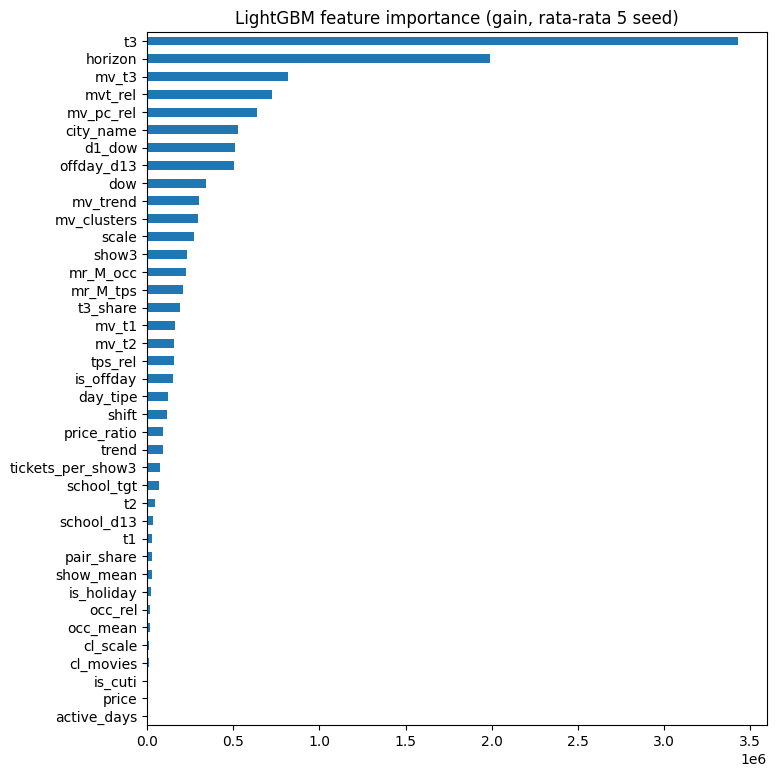

In [28]:
X_full = pd.concat([train_feat[FEATURES], aug_feat[FEATURES]])
y_full = np.concatenate([y, aug_feat["target_ratio"].values])
final_models = [LGBMRegressor(**{**LGBM_PARAMS, "random_state": s}).fit(X_full, y_full) for s in SEEDS]
test_feat["pred_ratio"] = np.mean([np.clip(m.predict(test_feat[FEATURES]), 0, None) for m in final_models], axis=0)


importance = pd.Series(np.mean([m.booster_.feature_importance(importance_type="gain") for m in final_models], axis=0),
                       index=FEATURES).sort_values()
importance.plot(kind="barh", figsize=(8, 9), title="LightGBM feature importance (gain, rata-rata 5 seed)")
plt.show()

# 8. Evaluation

### 8.1 Error OOF per horizon, skala pasangan, dan pola hari aktif

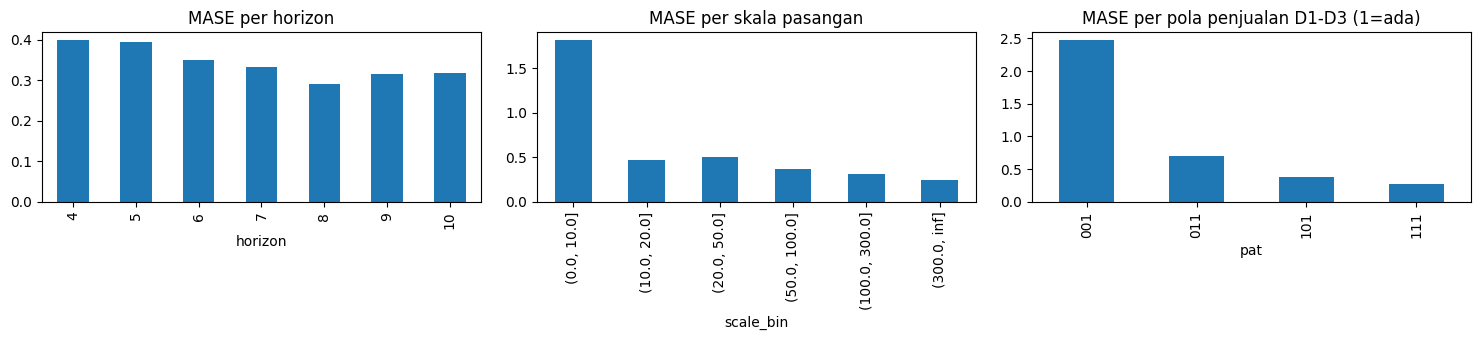

OOF MASE (CV): 0.3419 | dibobot komposisi test: 0.3614


In [29]:
ev = train_feat[["horizon", "scale", "target_ratio"]].assign(oof=oof, err=np.abs(y - oof), pat=pattern(train_feat).values)
ev["scale_bin"] = pd.cut(ev["scale"], [0, 10, 20, 50, 100, 300, np.inf])
fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ev.groupby("horizon")["err"].mean().plot(kind="bar", ax=ax[0], title="MASE per horizon")
ev.groupby("scale_bin", observed=True)["err"].mean().plot(kind="bar", ax=ax[1], title="MASE per skala pasangan")
ev.groupby("pat")["err"].mean().plot(kind="bar", ax=ax[2], title="MASE per pola penjualan D1-D3 (1=ada)")
plt.tight_layout(); plt.show()
print(f"OOF MASE (CV): {ev['err'].mean():.4f} | dibobot komposisi test: {np.average(ev['err'], weights=W_TEST):.4f}")

Error terbesar ada pada pasangan berskala kecil dan pasangan yang baru mulai tayang di D2/D3 (pola `001`, `011`). Pada pasangan seperti ini skala MASE sangat kecil, sehingga selisih beberapa tiket saja menjadi error besar.

### 8.2 Kurva prediksi vs aktual (OOF)

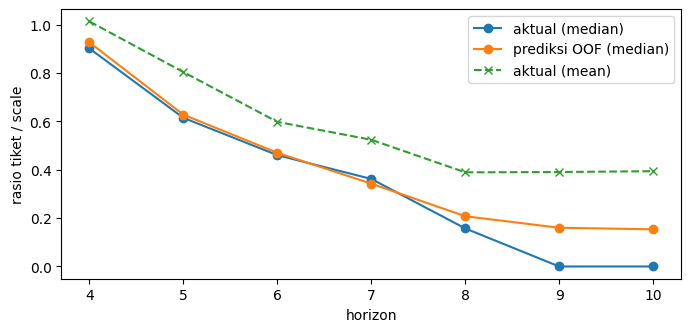

In [30]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ev.groupby("horizon")["target_ratio"].median().plot(marker="o", ax=ax, label="aktual (median)")
ev.groupby("horizon")["oof"].median().plot(marker="o", ax=ax, label="prediksi OOF (median)")
ev.groupby("horizon")["target_ratio"].mean().plot(marker="x", ls="--", ax=ax, label="aktual (mean)")
ax.set_ylabel("rasio tiket / scale"); ax.legend(); plt.show()

# 9. Postprocessing: kalibrasi level per musim dan horizon

Validasi train mengukur **ranking** (pasangan mana yang bertahan dan mana yang turun) dengan baik, tetapi tidak bisa mengukur **level** penjualan di periode uji. Musimnya berbeda: train tidak punya Natal–Tahun Baru, Ramadan, maupun minggu Lebaran sesudah Ramadan. Dari riwayat submission tim, pola yang konsisten adalah:
- Setiap kali train CV membaik karena level prediksi berubah, public LB justru memburuk (lima kali, lihat `leon/logs.md`).
- Gain LB terbesar datang dari **level**: grup Lebaran ×3 dari model mentah (0,45395 → 0,44518) dan baris lain ×1,2 (→ 0,44318).
- Ketika model lain di-*leveling* ke level per sel tersebut (rata-rata prediksi per grup musim × horizon disamakan), ranking yang lebih baik langsung terlihat di LB (→ 0,43729).

Karena itu, model final memberi **ranking**, sedangkan **level** setiap sel (grup musim × horizon D4–D10) disamakan dengan level yang sudah teruji di public LB. Target level di bawah adalah rata-rata `prediksi / scale` per sel dari submission tim yang skornya 0,44318 dan 0,43729 (kedua file punya rata-rata per sel yang sama persis). Di dalam setiap sel, urutan dan perbandingan antar pasangan tetap berasal dari model final.

Grup musim (berdasarkan tanggal saja):
- `ram_to_lebaran`: D1–D3 menyentuh Ramadan, target ≥ 20 Maret 2026 (Idulfitri)
- `ram_to_ram`: D1–D3 menyentuh Ramadan, target masih di Ramadan
- `pre_to_ram`: D1–D3 sebelum Ramadan, target di Ramadan
- `xmas`: target 20 Desember 2025 – 4 Januari 2026
- `normal`: sisanya

Ramadan 1447 H = 18 Februari – 19 Maret 2026, mengikuti Kalender Hijriah Global Tunggal (KHGT) Muhammadiyah yang dirilis publik 25 Juni 2025 (sebelum cutoff), konsisten dengan Idulfitri di `holidays.csv` dan SKB 3 Menteri 2026.

In [31]:
RAMADAN_START, LEBARAN_START = pd.Timestamp("2026-02-18"), pd.Timestamp("2026-03-20")
XMAS_START, XMAS_END = pd.Timestamp("2025-12-20"), pd.Timestamp("2026-01-04")

# rata-rata prediksi / scale per sel pada submission tim yang teruji di public LB (0,44318 dan 0,43729)
LEVEL_TARGETS = {
    "normal":         {4: 1.09238, 5: 0.75326, 6: 0.52880, 7: 0.42240, 8: 0.27042, 9: 0.23851, 10: 0.25945},
    "xmas":           {4: 1.63899, 5: 1.38849, 6: 0.86635, 7: 0.80614, 8: 0.76813, 9: 0.82710, 10: 0.60702},
    "ram_to_ram":     {4: 1.03569, 5: 0.79992, 6: 0.43042, 7: 0.27791, 8: 0.11918, 9: 0.07881, 10: 0.08247},
    "pre_to_ram":     {6: 0.54178, 7: 0.26053, 8: 0.17829, 9: 0.18066, 10: 0.17520},
    "ram_to_lebaran": {4: 3.16565, 5: 2.61646, 6: 2.74534, 7: 2.17368, 8: 1.06818, 9: 0.94552, 10: 0.74003},
}


def season_group(df):
    d13 = [df["d1_date"] + pd.Timedelta(days=k) for k in range(3)]
    d13_ramadan = np.any([(d >= RAMADAN_START) & (d < LEBARAN_START) for d in d13], axis=0)
    t = df["date_show"]
    t_ramadan = ((t >= RAMADAN_START) & (t < LEBARAN_START)).values
    xmas = ((t >= XMAS_START) & (t <= XMAS_END)).values
    return np.select([d13_ramadan & (t >= LEBARAN_START).values, d13_ramadan & t_ramadan, ~d13_ramadan & t_ramadan, xmas],
                     ["ram_to_lebaran", "ram_to_ram", "pre_to_ram", "xmas"], "normal")


test_feat["season_group"] = season_group(test_feat)
cell_mean = test_feat.groupby(["season_group", "horizon"])["pred_ratio"].transform("mean")
cell_target = [LEVEL_TARGETS[g][h] for g, h in zip(test_feat["season_group"], test_feat["horizon"])]
test_feat["level_factor"] = np.asarray(cell_target) / cell_mean
test_feat["final_ratio"] = test_feat["pred_ratio"] * test_feat["level_factor"]
test_feat["total_ticket"] = test_feat["final_ratio"] * test_feat["scale"]

print(test_feat["season_group"].value_counts().to_dict())
test_feat.groupby(["season_group", "horizon"])["level_factor"].first().unstack().round(3)

{'normal': 50049, 'ram_to_ram': 10767, 'xmas': 5235, 'ram_to_lebaran': 4598, 'pre_to_ram': 1962}


horizon,4,5,6,7,8,9,10
season_group,,,,,,,
normal,1.250,1.198,1.208,1.195,1.019,1.021,0.979
pre_to_ram,NaN,NaN,1.219,0.793,0.702,0.764,0.742
ram_to_lebaran,5.761,5.721,7.693,6.735,4.315,4.762,5.466
ram_to_ram,1.509,1.375,1.275,1.034,0.587,0.515,0.512
xmas,1.575,1.603,1.631,1.650,1.733,1.647,1.719


Faktor per sel menunjukkan di mana model (yang dilatih pada periode April–September) meleset levelnya di periode uji:
- grup normal perlu sekitar ×1,2 pada D4–D7, tetapi hampir ×1,0 pada D8–D10 (model final sudah lebih "bertahan" di hari-hari akhir);
- Natal perlu sekitar ×1,6;
- akhir Ramadan perlu diturunkan (sekitar ×0,5 di D8–D10);
- minggu Lebaran perlu ×4–7, karena pola ini sama sekali tidak ada di train.

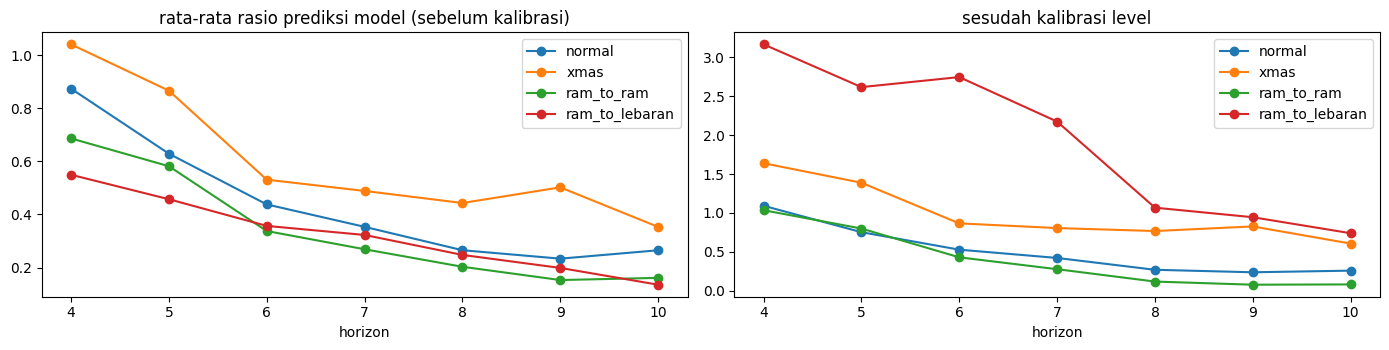

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 3.6))
for g in ["normal", "xmas", "ram_to_ram", "ram_to_lebaran"]:
    m = test_feat["season_group"] == g
    test_feat[m].groupby("horizon")["pred_ratio"].mean().plot(ax=ax[0], marker="o", label=g)
    test_feat[m].groupby("horizon")["final_ratio"].mean().plot(ax=ax[1], marker="o", label=g)
ax[0].set_title("rata-rata rasio prediksi model (sebelum kalibrasi)"); ax[1].set_title("sesudah kalibrasi level")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()

# 10. Submission

In [33]:
submission = test.merge(test_feat[["movie_title", "cinema_ids", "date_show", "total_ticket"]],
                        on=["movie_title", "cinema_ids", "date_show"], how="left")[["id", "total_ticket"]]
submission = sample_sub[["id"]].merge(submission, on="id", how="left")
assert len(submission) == len(sample_sub) == 72611
assert submission["total_ticket"].notna().all() and (submission["total_ticket"] >= 0).all()
submission.to_csv("submission.csv", index=False)

joblib.dump({"models": final_models, "features": FEATURES, "params": LGBM_PARAMS, "seeds": SEEDS,
             "aug_shifts": AUG_SHIFTS, "level_targets": LEVEL_TARGETS}, "fayadh_model.pkl")
print("submission.csv dan fayadh_model.pkl tersimpan,", f"ukuran model {os.path.getsize('fayadh_model.pkl') / 1e6:.2f} MB")
submission.describe().T

submission.csv dan fayadh_model.pkl tersimpan, ukuran model 18.49 MB


,count,mean,std,min,25%,50%,75%,max
id,72611.0,36306.000000,20961.134535,1.0,18153.500000,36306.000000,54458.500000,72611.000000
total_ticket,72611.0,197.576948,608.478930,0.0,2.688076,41.522343,177.158917,36330.356848


# 11. Kesimpulan
- Masalah ini adalah *cold-start forecasting*: 150 dari 160 film uji tidak pernah ada di train, dan periode uji berada setelah periode train.
- Memprediksi **rasio terhadap rata-rata D1–D3** dengan **objective L1** membuat loss training sama persis dengan metrik MASE.
- **Indeks pasar** dari penjualan D1–D3 film baru membuat performa film dibaca relatif terhadap kondisi pasarnya, karena periode uji jauh lebih sepi.
- **Augmentasi jendela bergeser** (shift 1–14 hari) memperbanyak data latih sekitar 9 kali lipat dan memberi perbaikan terbesar pada CV.
- **Kalender eksternal** (cuti bersama SKB 3 Menteri, libur sekolah DKI) membantu model memahami hari libur efektif di D1–D3 maupun di tanggal target.
- Train CV turun dari 0,3893 (pipeline tim sebelumnya) ke 0,3419. Level per musim × horizon, yang tidak bisa dipelajari dari train, dikalibrasi ke level yang sudah teruji di public LB.

Catatan reproduktibilitas: seluruh proses acak memakai `SEED = 42` (model final: 5 model dengan seed 42–46), dan LightGBM dijalankan dengan `deterministic=True` serta `force_row_wise=True` (dua kali run penuh menghasilkan `submission.csv` yang identik). Data eksternal hanya berupa tanggal (cuti bersama, libur sekolah, Ramadan) dengan sumber yang tercantum. Tidak ada data penjualan film uji dari luar dataset lomba yang dipakai.